# Momentum Engineering (Notebook)

This notebook mirrors `momentum.py` and adds visual checks at each step.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
BASE_DIR = Path(".")
valid_bookings_df = pd.read_parquet(BASE_DIR / "valid_bookings.parquet")
valid_bookings_df.head()

,has_promptpay,has_cc,has_shopee_pay,has_special_request,medium,created_at,prepared,refund,adjusted,ack,...,adult,end_time,start_time,active,revenue_dollars,booking_date,day_of_week_index,day_of_week,is_outlier,outlier_reason
3,NaN,NaN,NaN,NaN,<NA>,2023-08-13T05:47:00.000000,False,False,False,True,...,1,19:00:00,19:00:00,True,149.93,2025-05-13,1,Tuesday,False,
4,NaN,1.0,0.0,0.0,Web,2023-08-24T12:38:03,False,False,False,True,...,2,19:00:00,19:00:00,True,302.25,2024-06-17,0,Monday,False,
8,NaN,1.0,0.0,0.0,Web,2023-08-26T13:45:03,False,False,False,True,...,3,19:00:00,19:00:00,True,590.36,2024-06-06,3,Thursday,False,
10,NaN,NaN,NaN,1.0,Web,2023-09-22T03:57:13,False,False,False,True,...,2,18:00:00,17:00:00,True,199.60,2024-03-28,3,Thursday,False,
11,NaN,1.0,0.0,0.0,iOS,2023-09-25T03:09:57,False,False,False,True,...,7,18:00:00,18:00:00,True,1057.87,2025-12-18,3,Thursday,False,


In [2]:
#remove outliers from restaurant_id based on google sheet 
outlier_ids = [4503, 4502, 933, 837]
valid_bookings_df = valid_bookings_df[~valid_bookings_df['restaurant_id'].isin(outlier_ids)]
valid_bookings_df.shape


(452349, 29)

In [3]:
BASE_PATH = Path.cwd().parent.parent
PARQUET_PATH = BASE_PATH / "data" / "mv_dataset_parquet"
restaurants = pd.read_parquet(PARQUET_PATH / "restaurants.parquet")
restaurants.shape

(2474, 3)

In [4]:
valid_bookings_df = valid_bookings_df.merge(restaurants, on="restaurant_id", how="left")
valid_bookings_df.head()

,has_promptpay,has_cc,has_shopee_pay,has_special_request,medium,created_at,prepared,refund,adjusted,ack,...,start_time,active,revenue_dollars,booking_date,day_of_week_index,day_of_week,is_outlier,outlier_reason,name,days_in_advance
0,NaN,NaN,NaN,1.0,Web,2023-09-22T03:57:13,False,False,False,True,...,17:00:00,True,199.6,2024-03-28,3,Thursday,False,,Vantage Point QSNCC,180.0
1,1.0,NaN,0.0,1.0,Web,2023-10-16T13:37:18,False,False,False,True,...,19:00:00,True,232.8,2024-02-10,5,Saturday,False,,Place Bangkok,90.0
2,NaN,NaN,0.0,0.0,iOS,2023-10-24T14:44:53,False,False,False,True,...,17:00:00,True,1119.8,2024-01-20,5,Saturday,False,,Chatrium Hotel Riverside Bangkok Staycation,90.0
3,1.0,NaN,0.0,0.0,Web,2023-10-25T09:38:08,False,False,False,True,...,14:00:00,True,180.0,2024-03-30,5,Saturday,False,,<NA>,NaN
4,NaN,NaN,0.0,1.0,iOS,2023-10-28T04:42:45,False,False,False,True,...,18:00:00,True,199.6,2024-01-21,6,Sunday,False,,Vantage Point QSNCC,180.0


In [5]:
#retrieve places api data from csv
CSV_PATH = BASE_PATH / "_1_eda" / "places_api_new_results.csv"

# Load the CSV
google_restaurants_df = pd.read_csv(CSV_PATH)
google_restaurants_df.shape

(2392, 12)

In [6]:
valid_bookings_df = valid_bookings_df.merge(google_restaurants_df, left_on='name', right_on='input_string', how='left')
valid_bookings_df.head()

,has_promptpay,has_cc,has_shopee_pay,has_special_request,medium,created_at,prepared,refund,adjusted,ack,...,official_name,city,country,formatted_address,rating,website,error,Cuisine,Cuisine_confidence,raw_types
0,NaN,NaN,NaN,1.0,Web,2023-09-22T03:57:13,False,False,False,True,...,Vantage Point,NaN,Thailand,ชั้น 2 เลขที่ 60 Queen Sirikit National Conven...,4.2,https://www.facebook.com/VantagePointRestaurante,API key not valid. Please pass a valid API key.,General,0.15,"buffet_restaurant,restaurant,food,point_of_int..."
1,1.0,NaN,0.0,1.0,Web,2023-10-16T13:37:18,False,False,False,True,...,place.bangkok,NaN,Thailand,"73/3 ซอย อินทามระ 4 Khwaeng Samsen Nai, Khet P...",4.4,https://www.facebook.com/placebangkok/,API key not valid. Please pass a valid API key.,Italian,0.70,"italian_restaurant,restaurant,point_of_interes..."
2,NaN,NaN,0.0,0.0,iOS,2023-10-24T14:44:53,False,False,False,True,...,Chatrium Hotel Riverside Bangkok,NaN,Thailand,"28 ถ. เจริญกรุง Khwaeng Wat Phraya Krai, Khet ...",4.6,https://www.chatrium.com/chatriumriversidebang...,API key not valid. Please pass a valid API key.,NaN,0.20,"hotel,lodging,point_of_interest,establishment"
3,1.0,NaN,0.0,0.0,Web,2023-10-25T09:38:08,False,False,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,0.0,1.0,iOS,2023-10-28T04:42:45,False,False,False,True,...,Vantage Point,NaN,Thailand,ชั้น 2 เลขที่ 60 Queen Sirikit National Conven...,4.2,https://www.facebook.com/VantagePointRestaurante,API key not valid. Please pass a valid API key.,General,0.15,"buffet_restaurant,restaurant,food,point_of_int..."


In [7]:
# 1. Create a deep copy to avoid SettingWithCopy warnings
clean_bookings_df = valid_bookings_df.copy()

# 2. Count before for your records
initial_count = len(clean_bookings_df)
print (f"Initial records: {initial_count}")

# 3. Drop records where user_id_masked is an empty string or NaN
clean_bookings_df = clean_bookings_df[
    (clean_bookings_df['user_id_masked'] != "") & 
    (clean_bookings_df['user_id_masked'].notna())
]

# 4. Verification
removed_count = initial_count - len(clean_bookings_df)
print(f"Removed {removed_count} records with empty or null user_id_masked.")
print(f"Remaining records: {len(clean_bookings_df)}")

Initial records: 452349
Removed 135856 records with empty or null user_id_masked.
Remaining records: 316493


In [8]:
# The 'Gold Standard' for identifying these specific system duplicates
logic_columns = [
    'user_id_masked', 
    'restaurant_id', 
    'booking_date', 
    'start_time', 
    'end_time', 
    'active'
]

# Identify the duplicates
duplicate_mask = clean_bookings_df.duplicated(subset=logic_columns, keep=False)
duplicates_only = clean_bookings_df[duplicate_mask].sort_values(by=['user_id_masked', 'id'])

# Count them
unique_duplicate_events = duplicates_only.groupby(logic_columns).ngroups

print(f"Identified {unique_duplicate_events} events that have redundant system entries.")

Identified 2720 events that have redundant system entries.


In [14]:
# Select only the identifying columns to verify they are identical
verification_cols = ['id', 'user_id_masked', 'restaurant_id', 'booking_date', 'start_time', 'end_time', 'revenue_dollars', 'active']

# View the top 20 duplicates with these specific columns
duplicates_only[verification_cols].head(20)

,id,user_id_masked,restaurant_id,booking_date,start_time,end_time,revenue_dollars,active
279293,7485531,10004982607977776954,894,2025-05-11,13:00:00,15:00:00,226.40,True
279295,7485538,10004982607977776954,894,2025-05-11,13:00:00,15:00:00,136.00,True
163625,6392572,1002398865849034957,2592,2024-11-13,18:00:00,18:00:00,1099.00,True
163630,6392601,1002398865849034957,2592,2024-11-13,18:00:00,18:00:00,769.30,True
327266,7755687,10038524973759102977,4385,2025-07-26,18:00:00,20:00:00,76.56,True
327276,7755712,10038524973759102977,4385,2025-07-26,18:00:00,20:00:00,76.56,True
81665,5264161,10049410200564458075,3279,2024-07-07,12:00:00,12:00:00,99.90,True
81667,5264174,10049410200564458075,3279,2024-07-07,12:00:00,12:00:00,99.90,True
81668,5264186,10049410200564458075,3279,2024-07-07,12:00:00,12:00:00,99.90,True
236,3991557,10050903249521646579,2001,2024-02-04,12:00:00,14:00:00,1505.00,True


In [10]:
# We sort by ID descending so the highest ID appears first for each group
final_bookings_df = clean_bookings_df.sort_values('id', ascending=False).drop_duplicates(
    subset=logic_columns, 
    keep='first'
)

In [ ]:
# Calculate the IDs that were removed (the "old_transaction_ids")
all_ids = set(clean_bookings_df['id'])
kept_ids = set(final_bookings_df['id'])
old_transaction_ids = list(all_ids - kept_ids)

print(f"Original Records: {len(clean_bookings_df)}")
print(f"Cleaned Records: {len(final_bookings_df)}")
print(f"Total 'Old' IDs identified for deletion: {len(old_transaction_ids)}")

Original Records: 316493
Cleaned Records: 313276
Total 'Old' IDs identified for deletion: 3149


## 0) Guardrails / required cols

In [18]:
import requests

# 1. Setup Currency Reference
country_to_currency = {
    'Thailand': 'THB', 'Singapore': 'SGD', 'Malaysia': 'MYR',
    'United States': 'USD', 'Japan': 'JPY', 'Hong Kong': 'HKD',
    'United Kingdom': 'GBP', 'Australia': 'AUD', 'Vietnam': 'VND',
    'Indonesia': 'IDR', 'India': 'INR', 'France': 'EUR',
    'Italy': 'EUR', 'Netherlands': 'EUR'
}

# 2. Fetch Live Rates
def get_live_rates(base_currency='USD'):
    url = f"https://open.er-api.com/v6/latest/{base_currency}"
    try:
        response = requests.get(url)
        data = response.json()
        if data['result'] == 'success':
            return data['rates']
    except Exception:
        pass
    # Fallback to approx rates if API is down
    return {'THB': 35.5, 'SGD': 1.34, 'MYR': 4.7, 'JPY': 150.0, 'USD': 1.0, 'EUR': 0.92}

exchange_rates = get_live_rates('USD')

# 3. Clean and Validate DataFrame
# Note: Ensure 'country' and 'revenue_dollars' exist for the conversion to work
required_cols = ["restaurant_id", "booking_date", "id", "revenue_dollars", "country"]
missing = [c for c in required_cols if c not in final_bookings_df.columns]
if missing:
    raise ValueError(f"final_bookings_df missing required columns: {missing}")

# Handle Dates and NaNs
final_bookings_df["booking_date"] = pd.to_datetime(final_bookings_df["booking_date"], errors="coerce")
final_bookings_df = final_bookings_df.dropna(subset=["booking_date", "restaurant_id"])

# 4. Apply Currency Conversion
def perform_conversion(row):
    country = row['country']
    amount = row['revenue_dollars']
    currency_code = country_to_currency.get(country)
    
    if currency_code and pd.notnull(amount):
        rate = exchange_rates.get(currency_code)
        if rate:
            # API gives 1 USD = X Local. So we divide Local / Rate to get USD.
            return amount / rate
    return amount

final_bookings_df["revenue_usd"] = final_bookings_df.apply(perform_conversion, axis=1)

# 5. Handle Guest Logic
if "total_guests" not in final_bookings_df.columns:
    if "adult" in final_bookings_df.columns and "kids" in final_bookings_df.columns:
        final_bookings_df["total_guests"] = (
            final_bookings_df["adult"].fillna(0) + final_bookings_df["kids"].fillna(0)
        )
    else:
        final_bookings_df["total_guests"] = np.nan

print(f"Final Shape: {final_bookings_df.shape}")

Final Shape: (313276, 45)


In [20]:
final_bookings_df.head(10)

,has_promptpay,has_cc,has_shopee_pay,has_special_request,medium,created_at,prepared,refund,adjusted,ack,...,country,formatted_address,rating,website,error,Cuisine,Cuisine_confidence,raw_types,revenue_usd,total_guests
452348,NaN,NaN,0.0,0.0,Android,2026-01-07T04:50:49,False,False,False,True,...,Thailand,"B Floor, Banyan Tree Bangkok, 21/100 S Sathon ...",4.6,https://www.banyantree.com/thailand/bangkok/di...,API key not valid. Please pass a valid API key.,Thai,0.70,"buffet_restaurant,thai_restaurant,asian_restau...",2.529816,1
452346,NaN,NaN,0.0,0.0,iOS,2026-01-07T04:50:12,False,False,False,True,...,Thailand,"Siphya, 2 ถ. เจริญกรุง แขวงบางรัก เขตบางรัก กร...",4.5,https://www.marriott.com/en-us/dining/restaura...,API key not valid. Please pass a valid API key.,Italian,0.70,"italian_restaurant,restaurant,food,point_of_in...",4.401056,2
452343,NaN,NaN,0.0,0.0,Web,2026-01-07T04:47:17,False,False,False,True,...,Thailand,"Kimpton Maa-Lai Bangkok, Soi Ton Son, Khwaeng ...",4.7,https://bit.ly/GGStockRoom,API key not valid. Please pass a valid API key.,General,0.15,"restaurant,food,point_of_interest,establishment",6.269131,2
452340,1.0,NaN,0.0,0.0,iOS,2026-01-07T04:46:48,False,False,False,True,...,Thailand,"55 ถนน ศรีนครินทร์ Khwaeng Nong Bon, Khet Praw...",4.7,http://www.boontongkeethailand.com/home/out-ou...,API key not valid. Please pass a valid API key.,General,0.15,"restaurant,food,point_of_interest,establishment",4.369394,4
452338,1.0,NaN,0.0,0.0,Android,2026-01-07T04:45:14,False,False,False,True,...,Thailand,"Queen Sirikit National Convention Center, 60 T...",4.1,https://foa.co.th/,API key not valid. Please pass a valid API key.,Chinese,0.70,"chinese_restaurant,restaurant,point_of_interes...",11.160952,4
452336,NaN,1.0,0.0,0.0,iOS,2026-01-07T04:43:41,False,False,False,True,...,Thailand,"1 Rachadaphisek Road, Fortune Town, แขวงดินแดง...",4.4,NaN,API key not valid. Please pass a valid API key.,Chinese,0.70,"chinese_restaurant,restaurant,food,point_of_in...",3.035779,1
452334,NaN,NaN,0.0,0.0,iOS,2026-01-07T04:41:50,False,False,False,True,...,Thailand,"166, 1-5 ถนน รัชดา 10 Khwaeng Huai Khwang, Khe...",4.4,https://www.facebook.com/kuangseafood2,API key not valid. Please pass a valid API key.,Seafood,0.70,"seafood_restaurant,restaurant,point_of_interes...",28.875996,8
452332,NaN,1.0,0.0,0.0,iOS,2026-01-07T04:38:50,False,False,False,True,...,Thailand,เลขที่ 9/8-9 Kagonoya ชั้น 7 ห้อง 730 Thanon R...,3.3,https://m.facebook.com/kagonoyathailand,API key not valid. Please pass a valid API key.,Japanese,0.70,"japanese_restaurant,restaurant,food,point_of_i...",12.300794,5
452331,NaN,NaN,0.0,0.0,Android,2026-01-07T04:37:46,False,False,False,True,...,Thailand,"24th floor, Centara Grand and Bangkok Conventi...",4.3,https://www.ventisibangkok.com/,API key not valid. Please pass a valid API key.,General,0.15,"restaurant,point_of_interest,food,establishment",25.076523,8
452330,NaN,NaN,0.0,0.0,Web,2026-01-07T04:35:34,False,False,False,True,...,Thailand,"Ground Level Chatrium 728 Thanon Phetchaburi, ...",4.7,https://www.chatrium.com/grandbangkok/savio,API key not valid. Please pass a valid API key.,General,0.15,"restaurant,point_of_interest,food,establishment",7.124012,3


## 1) Monthly aggregation

In [32]:
final_bookings_df["year_month"] = final_bookings_df["booking_date"].dt.to_period("M").dt.to_timestamp()

# Filter out advance bookings beyond Dec 2025
cutoff_month = pd.Timestamp("2025-12-01")
final_bookings_df = final_bookings_df[final_bookings_df["year_month"] <= cutoff_month].copy()

restaurants_agg = (
    final_bookings_df
    .groupby(["restaurant_id", "year_month"], as_index=False)
    .agg(
        monthly_bookings=("id", "count"),
        monthly_revenue=("revenue_usd", "sum"),
        avg_revenue_per_booking=("revenue_usd", "mean"),
        avg_guests=("total_guests", "mean"),
        active_days=("booking_date", lambda x: x.dt.date.nunique()),
    )
)

#do note monthly_revenue here refers to the usd denominated revenue, please confirm based on above steps 
restaurants_agg["monthly_bookings"] = restaurants_agg["monthly_bookings"].fillna(0).astype(int)
restaurants_agg["monthly_revenue"] = restaurants_agg["monthly_revenue"].fillna(0.0)
restaurants_agg["avg_revenue_per_booking"] = restaurants_agg["avg_revenue_per_booking"].replace([np.inf, -np.inf], np.nan)
restaurants_agg["avg_revenue_per_booking"] = restaurants_agg["avg_revenue_per_booking"].fillna(0.0)

restaurants_agg = restaurants_agg.sort_values(["restaurant_id", "year_month"]).reset_index(drop=True)
restaurants_agg.head()

,restaurant_id,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days
0,33,2024-01-01,40,389.246528,9.731163,4.925000,11
1,33,2024-02-01,110,784.964193,7.136038,3.718182,23
2,33,2024-03-01,97,811.663091,8.367661,4.144330,29
3,33,2024-04-01,86,650.804795,7.567498,4.244186,27
4,33,2024-05-01,66,443.811396,6.724415,3.681818,28


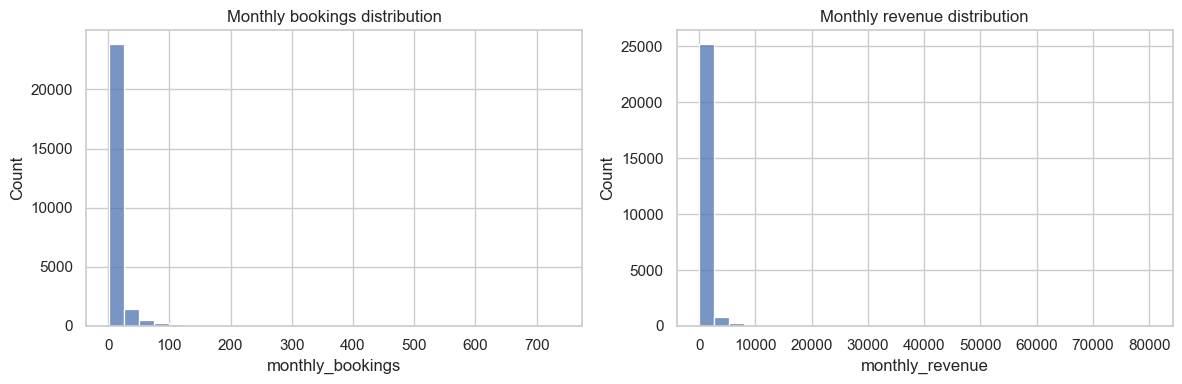

In [33]:
# Plot bookings and revenue distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(restaurants_agg["monthly_bookings"], bins=30, ax=axes[0])
axes[0].set_title("Monthly bookings distribution")

sns.histplot(restaurants_agg["monthly_revenue"], bins=30, ax=axes[1])
axes[1].set_title("Monthly revenue distribution")
plt.tight_layout()

## 2) Minimum history filter

In [34]:
MIN_MONTHS = 3
hist = restaurants_agg.groupby("restaurant_id")["year_month"].nunique()
keep_ids = hist[hist >= MIN_MONTHS].index
restaurants_agg = restaurants_agg[restaurants_agg["restaurant_id"].isin(keep_ids)].copy()
restaurants_agg.shape

(25490, 7)

## 3) Winsorise extremes

In [35]:
def winsorise_series(s: pd.Series, lower_q=0.01, upper_q=0.99) -> pd.Series:
    lo = s.quantile(lower_q)
    hi = s.quantile(upper_q)
    return s.clip(lower=lo, upper=hi)

for col in ["monthly_bookings", "monthly_revenue", "avg_revenue_per_booking"]:
    restaurants_agg[col] = winsorise_series(restaurants_agg[col])

restaurants_agg[["monthly_bookings","monthly_revenue","avg_revenue_per_booking"]].describe().T

,count,mean,std,min,25%,50%,75%,max
monthly_bookings,25490.0,11.186661,21.710558,1.000000,1.000000,3.000000,10.000000,137.000000
monthly_revenue,25490.0,569.756037,1518.977526,1.861742,13.796440,71.805022,362.362026,10668.934000
avg_revenue_per_booking,25490.0,71.915644,119.741566,1.551219,4.898797,9.564567,108.475642,616.872889


## 4) Growth + rolling growth

In [36]:
restaurants_agg["booking_growth_pct"] = (
    restaurants_agg.groupby("restaurant_id")["monthly_bookings"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
)

restaurants_agg["revenue_growth_pct"] = (
    restaurants_agg.groupby("restaurant_id")["monthly_revenue"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
)

ROLL = 3
restaurants_agg["booking_growth_rolling"] = (
    restaurants_agg.groupby("restaurant_id")["booking_growth_pct"]
    .rolling(ROLL, min_periods=ROLL)
    .mean()
    .reset_index(level=0, drop=True)
)

restaurants_agg["revenue_growth_rolling"] = (
    restaurants_agg.groupby("restaurant_id")["revenue_growth_pct"]
    .rolling(ROLL, min_periods=ROLL)
    .mean()
    .reset_index(level=0, drop=True)
)

restaurants_agg["booking_growth_rolling"] = restaurants_agg["booking_growth_rolling"].fillna(0.0)
restaurants_agg["revenue_growth_rolling"] = restaurants_agg["revenue_growth_rolling"].fillna(0.0)

restaurants_agg[["booking_growth_rolling","revenue_growth_rolling"]].describe().T

,count,mean,std,min,25%,50%,75%,max
booking_growth_rolling,25490.0,0.237738,0.610287,-0.619248,0.0,0.000000,0.333333,16.233333
revenue_growth_rolling,25490.0,0.340083,0.934660,-0.742750,0.0,0.022903,0.441029,34.772377


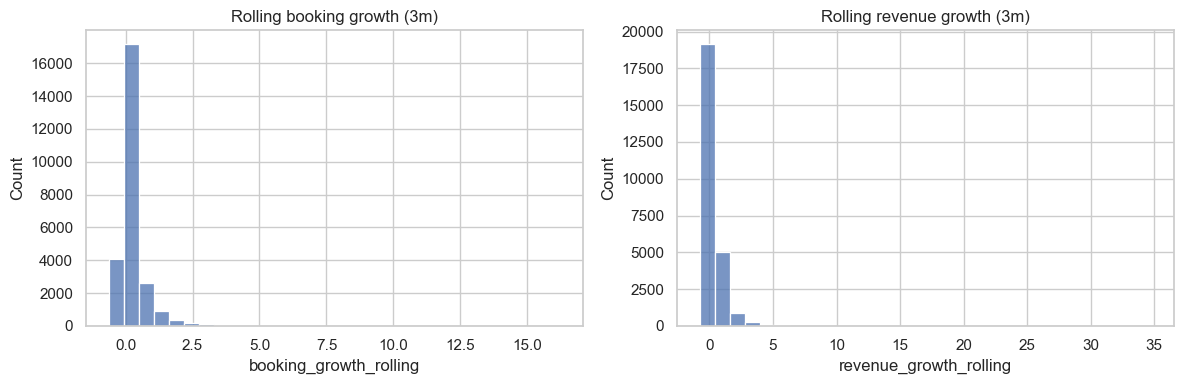

In [37]:
# Growth distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(restaurants_agg["booking_growth_rolling"], bins=30, ax=axes[0])
axes[0].set_title("Rolling booking growth (3m)")

sns.histplot(restaurants_agg["revenue_growth_rolling"], bins=30, ax=axes[1])
axes[1].set_title("Rolling revenue growth (3m)")
plt.tight_layout()

## 5) Standardize into comparable scores

In [38]:
def pct_rank(s: pd.Series) -> pd.Series:
    return s.rank(pct=True, method="average")

restaurants_agg["perf_bookings_rank"] = pct_rank(restaurants_agg["monthly_bookings"])
restaurants_agg["perf_spend_rank"] = pct_rank(restaurants_agg["avg_revenue_per_booking"])
restaurants_agg["performance_score"] = (restaurants_agg["perf_bookings_rank"] + restaurants_agg["perf_spend_rank"]) / 2

restaurants_agg["growth_bookings_rank"] = pct_rank(restaurants_agg["booking_growth_rolling"])
restaurants_agg["growth_revenue_rank"] = pct_rank(restaurants_agg["revenue_growth_rolling"])
restaurants_agg["growth_score"] = (restaurants_agg["growth_bookings_rank"] + restaurants_agg["growth_revenue_rank"]) / 2

restaurants_agg[["performance_score","growth_score"]].describe().T

,count,mean,std,min,25%,50%,75%,max
performance_score,25490.0,0.50002,0.207657,0.065418,0.349951,0.510651,0.656932,0.981375
growth_score,25490.0,0.50002,0.273317,0.000324,0.351913,0.383680,0.743385,0.999961


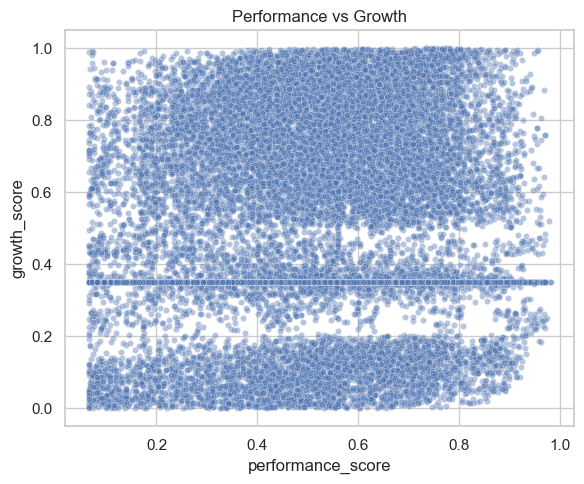

In [39]:
# Performance vs Growth scatter
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=restaurants_agg,
    x="performance_score",
    y="growth_score",
    alpha=0.4,
    s=20
)
plt.title("Performance vs Growth")
plt.tight_layout()

## 6) Composite momentum + segmentation

In [40]:
ALPHA = 0.5
restaurants_agg["momentum_score"] = ALPHA * restaurants_agg["performance_score"] + (1 - ALPHA) * restaurants_agg["growth_score"]

perf_cut = restaurants_agg["performance_score"].median()
grow_cut = restaurants_agg["growth_score"].median()

restaurants_agg["momentum_segment"] = np.select(
    [
        (restaurants_agg["performance_score"] >= perf_cut) & (restaurants_agg["growth_score"] >= grow_cut),
        (restaurants_agg["performance_score"] <  perf_cut) & (restaurants_agg["growth_score"] >= grow_cut),
        (restaurants_agg["performance_score"] >= perf_cut) & (restaurants_agg["growth_score"] <  grow_cut),
        (restaurants_agg["performance_score"] <  perf_cut) & (restaurants_agg["growth_score"] <  grow_cut),
    ],
    [
        "Rising Stars",
        "Emerging Opportunities",
        "Established Players",
        "Needs Attention",
    ],
    default="Unclassified"
)

restaurants_agg[["momentum_score","momentum_segment"]].head()

,momentum_score,momentum_segment
0,0.535882,Established Players
1,0.520023,Established Players
2,0.534548,Established Players
3,0.725932,Rising Stars
4,0.381238,Established Players


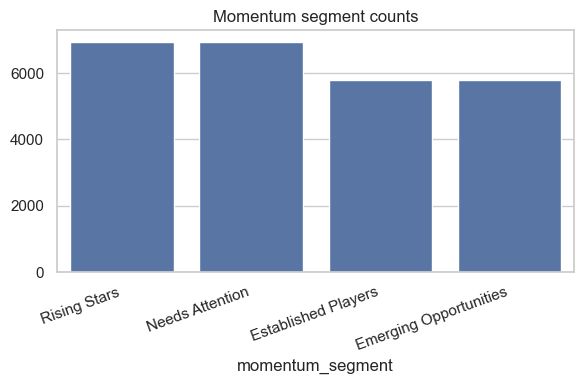

In [41]:
# Segment counts
plt.figure(figsize=(6, 4))
segment_counts = restaurants_agg["momentum_segment"].value_counts()
sns.barplot(x=segment_counts.index, y=segment_counts.values)
plt.title("Momentum segment counts")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

## 7) Latest-month prioritised list

In [42]:
latest_month = restaurants_agg["year_month"].max()
priority_latest = (
    restaurants_agg[restaurants_agg["year_month"] == latest_month]
    .sort_values("momentum_score", ascending=False)
    .reset_index(drop=True)
)

print("Latest month:", latest_month.date())
print(priority_latest["momentum_segment"].value_counts(dropna=False))
priority_latest.head(10)

Latest month: 2025-12-01
momentum_segment
Emerging Opportunities    466
Rising Stars              370
Needs Attention           239
Established Players        70
Name: count, dtype: int64


,restaurant_id,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days,booking_growth_pct,revenue_growth_pct,booking_growth_rolling,revenue_growth_rolling,perf_bookings_rank,perf_spend_rank,performance_score,growth_bookings_rank,growth_revenue_rank,growth_score,momentum_score,momentum_segment
0,4911,2025-12-01,10,10574.016939,616.872889,2.600000,7,9.000000,13.946667,3.166667,5.252289,0.753805,0.995018,0.874412,0.994959,0.995567,0.995263,0.934837,Rising Stars
1,6462,2025-12-01,90,1481.357600,16.459529,3.944444,24,-0.343066,-0.582797,4.626386,10.096615,0.977109,0.625736,0.801422,0.997882,0.999294,0.998588,0.900005,Rising Stars
2,5465,2025-12-01,34,1261.933303,37.115685,4.088235,14,0.172414,0.403444,3.140805,5.167766,0.921695,0.682660,0.802177,0.994704,0.995371,0.995037,0.898607,Rising Stars
3,701,2025-12-01,35,6041.307210,172.608777,2.314286,21,0.060606,-0.062560,0.917027,1.082201,0.924225,0.837152,0.880689,0.920989,0.903570,0.912279,0.896484,Rising Stars
4,2447,2025-12-01,69,10668.934000,208.579710,2.434783,26,0.095238,0.000000,0.832807,0.679284,0.965692,0.875716,0.920704,0.903648,0.830600,0.867124,0.893914,Rising Stars
5,565,2025-12-01,110,1580.710657,14.370097,4.681818,26,5.111111,5.628794,2.272498,3.081675,0.983601,0.602511,0.793056,0.986779,0.985798,0.986289,0.889672,Rising Stars
6,5685,2025-12-01,91,1465.168045,16.100748,5.340659,22,4.352941,7.591569,1.570028,2.513743,0.977579,0.621302,0.799441,0.969400,0.978580,0.973990,0.886715,Rising Stars
7,3933,2025-12-01,6,4318.080000,616.872889,3.500000,5,2.000000,0.615383,1.222222,1.777596,0.644311,0.995018,0.819665,0.950392,0.956650,0.953521,0.886593,Rising Stars
8,5098,2025-12-01,7,3275.640000,467.948571,2.857143,6,2.500000,3.551017,1.000000,1.317032,0.679874,0.980424,0.830149,0.929423,0.927187,0.928305,0.879227,Rising Stars
9,5657,2025-12-01,10,1844.400000,184.440000,3.000000,8,2.333333,3.813655,1.152778,1.962529,0.753805,0.851353,0.802579,0.945351,0.963986,0.954668,0.878624,Rising Stars


In [43]:
# Save latest-month list
output_path = BASE_DIR / "priority_latest_momentum_labels.parquet"
priority_latest.to_parquet(output_path, index=False)
print("Saved latest-month momentum labels to:", output_path)

Saved latest-month momentum labels to: priority_latest_momentum_labels.parquet
